In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

DATA_ROOT = "raw"

datasets = {
    "UIEB": ("raw", "reference"),
    "SUIM-E": ("raw", "reference"),
    "EUVP": ("raw", "reference")
}

records = []

widths = []
heights = []

r_vals = []
g_vals = []
b_vals = []

edge_raw = []
edge_ref = []

fft_raw = []
fft_ref = []


def high_freq_energy(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    f = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.abs(f)

    return magnitude.mean()


print("Scanning datasets...\n")

for dataset, (raw_folder, ref_folder) in datasets.items():

    raw_dir = Path(DATA_ROOT) / dataset / raw_folder
    ref_dir = Path(DATA_ROOT) / dataset / ref_folder

    files = sorted(os.listdir(raw_dir))

    for f in tqdm(files, desc=dataset):

        raw_path = raw_dir / f
        ref_path = ref_dir / f

        if not ref_path.exists():
            continue

        raw_img = cv2.imread(str(raw_path))
        ref_img = cv2.imread(str(ref_path))

        if raw_img is None or ref_img is None:
            continue

        if raw_img.shape != ref_img.shape:
            ref_img = cv2.resize(ref_img, (raw_img.shape[1], raw_img.shape[0]))

        h, w, _ = raw_img.shape

        widths.append(w)
        heights.append(h)

        r_vals.append(raw_img[:, :, 2].mean())
        g_vals.append(raw_img[:, :, 1].mean())
        b_vals.append(raw_img[:, :, 0].mean())

        psnr = peak_signal_noise_ratio(ref_img, raw_img)

        ssim = structural_similarity(
            ref_img,
            raw_img,
            channel_axis=2
        )

        raw_gray = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)
        ref_gray = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY)

        edge_raw.append(cv2.Canny(raw_gray, 100, 200).mean())
        edge_ref.append(cv2.Canny(ref_gray, 100, 200).mean())

        fft_raw.append(high_freq_energy(raw_img))
        fft_ref.append(high_freq_energy(ref_img))

        records.append({
            "dataset": dataset,
            "width": w,
            "height": h,
            "psnr": psnr,
            "ssim": ssim
        })


df = pd.DataFrame(records)

print("\nDataset Summary\n")
print(df.groupby("dataset")[["psnr", "ssim"]].mean())

os.makedirs("eda_outputs", exist_ok=True)

Scanning datasets...



EUVP: 100%|██████████| 11435/11435 [07:05<00:00, 26.88it/s]



Dataset Summary

              psnr      ssim
dataset                     
EUVP     17.071776  0.778268
SUIM-E   18.258521  0.814075
UIEB     17.355527  0.767609


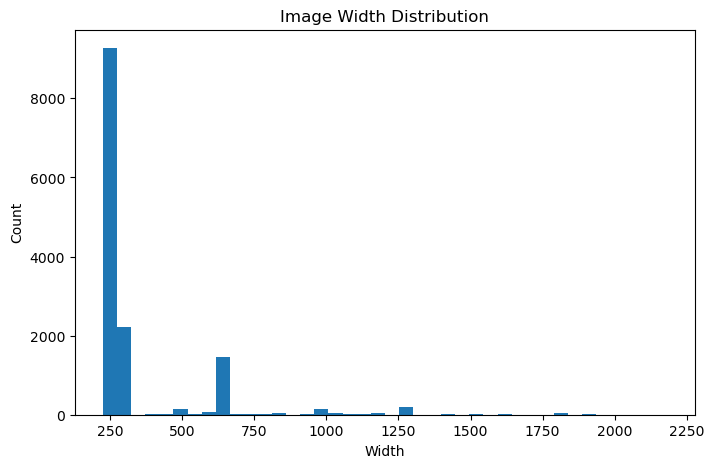

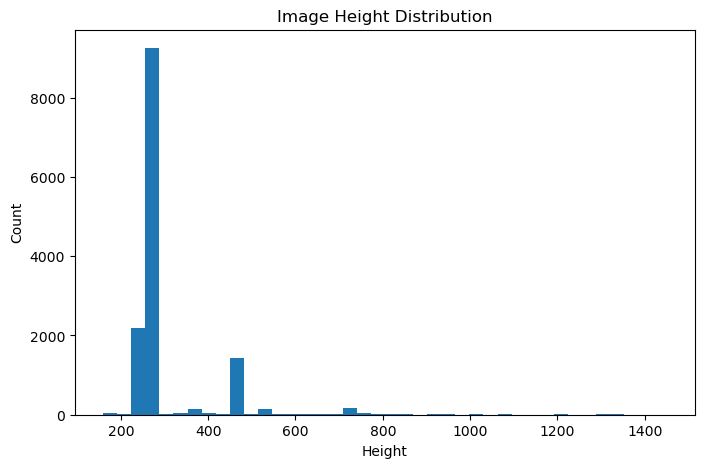

In [2]:
plt.figure(figsize=(8,5))
plt.hist(widths, bins=40)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.savefig("eda_outputs/width_distribution.png")
plt.show()


plt.figure(figsize=(8,5))
plt.hist(heights, bins=40)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.savefig("eda_outputs/height_distribution.png")
plt.show()

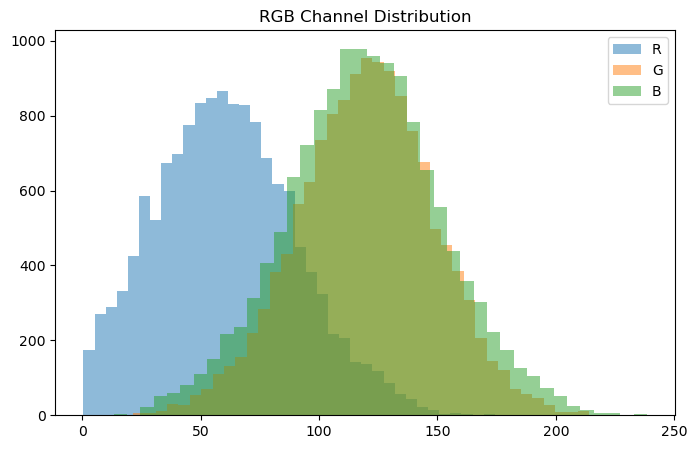

In [3]:
plt.figure(figsize=(8,5))

plt.hist(r_vals, bins=40, alpha=0.5, label="R")
plt.hist(g_vals, bins=40, alpha=0.5, label="G")
plt.hist(b_vals, bins=40, alpha=0.5, label="B")

plt.legend()
plt.title("RGB Channel Distribution")
plt.savefig("eda_outputs/rgb_distribution.png")
plt.show()

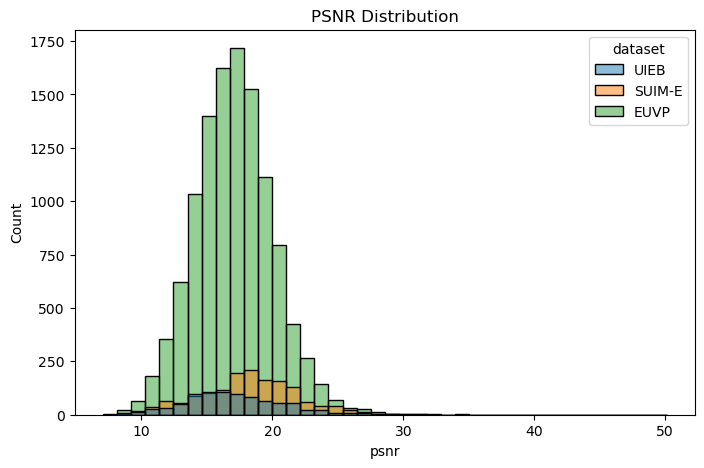

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="psnr", hue="dataset", bins=40)

plt.title("PSNR Distribution")
plt.savefig("eda_outputs/psnr_distribution.png")
plt.show()

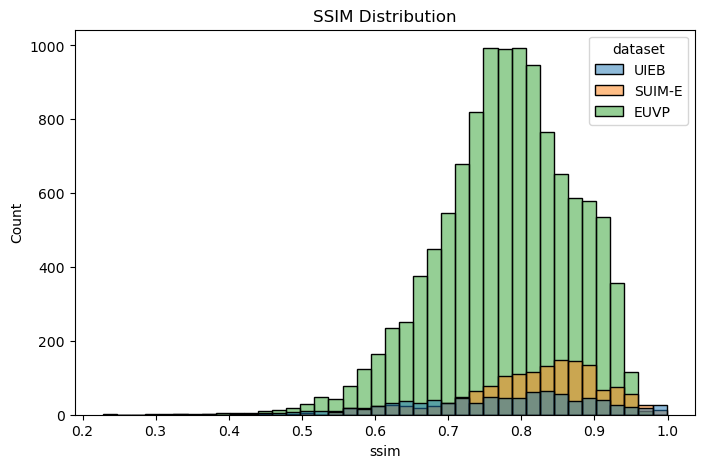

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="ssim", hue="dataset", bins=40)

plt.title("SSIM Distribution")
plt.savefig("eda_outputs/ssim_distribution.png")
plt.show()

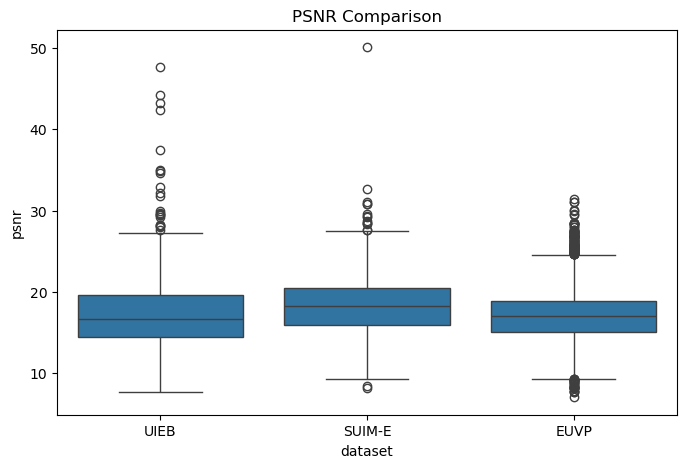

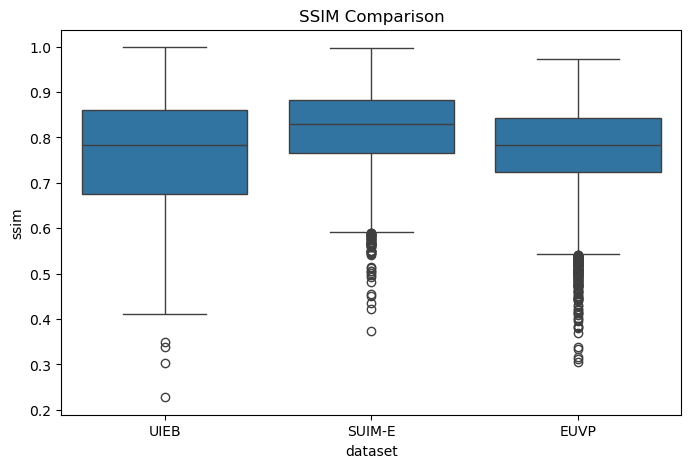

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="dataset", y="psnr")
plt.title("PSNR Comparison")
plt.savefig("eda_outputs/psnr_boxplot.png")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="dataset", y="ssim")
plt.title("SSIM Comparison")
plt.savefig("eda_outputs/ssim_boxplot.png")
plt.show()

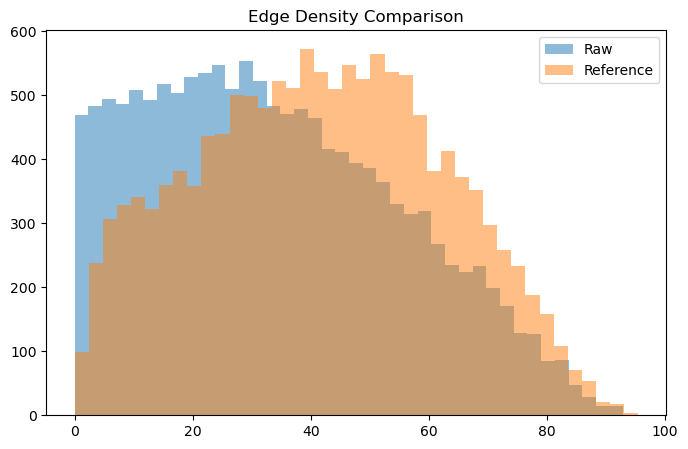

In [9]:
plt.figure(figsize=(8,5))

plt.hist(edge_raw, bins=40, alpha=0.5, label="Raw")
plt.hist(edge_ref, bins=40, alpha=0.5, label="Reference")

plt.legend()
plt.title("Edge Density Comparison")
plt.savefig("eda_outputs/edge_density.png")
plt.show()

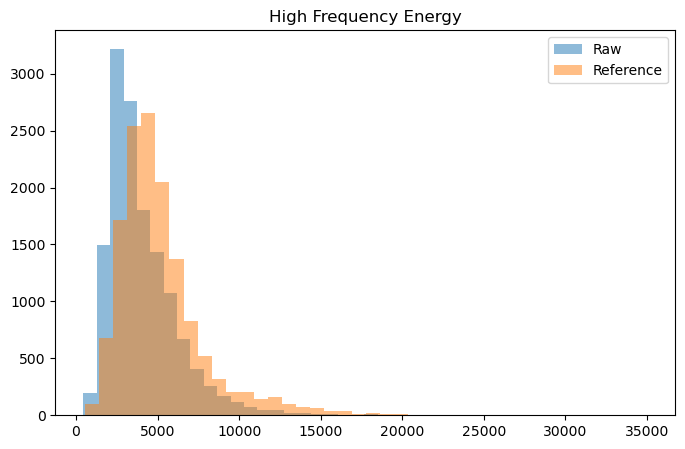

In [10]:
plt.figure(figsize=(8,5))

plt.hist(fft_raw, bins=40, alpha=0.5, label="Raw")
plt.hist(fft_ref, bins=40, alpha=0.5, label="Reference")

plt.legend()
plt.title("High Frequency Energy")
plt.savefig("eda_outputs/frequency_energy.png")
plt.show()

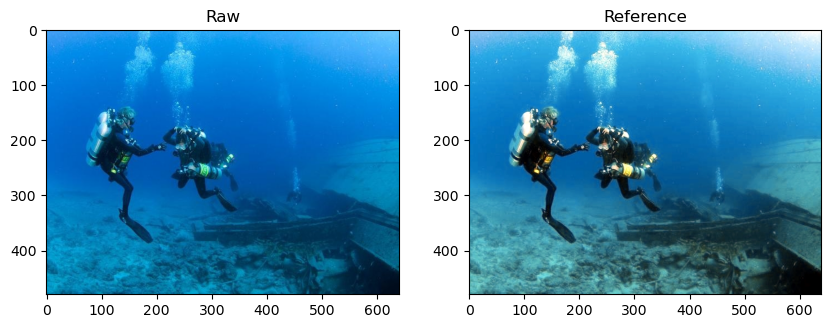

In [11]:
import random

sample = random.choice(records)

dataset = sample["dataset"]

raw_folder, ref_folder = datasets[dataset]

raw_dir = Path(DATA_ROOT)/dataset/raw_folder
ref_dir = Path(DATA_ROOT)/dataset/ref_folder

file = os.listdir(raw_dir)[0]

raw = cv2.imread(str(raw_dir/file))
ref = cv2.imread(str(ref_dir/file))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.title("Raw")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
plt.title("Reference")

plt.savefig("eda_outputs/sample_comparison.png")

plt.show()

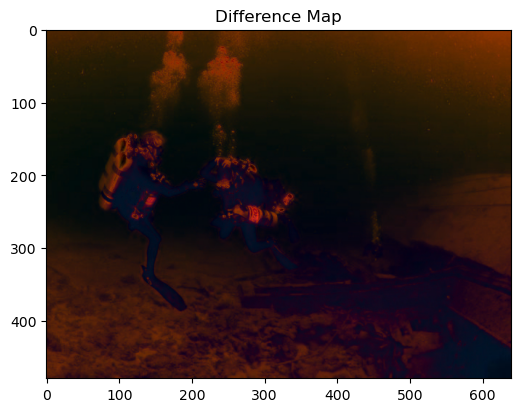

In [12]:
diff = cv2.absdiff(raw, ref)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
plt.title("Difference Map")
plt.savefig("eda_outputs/difference_map.png")
plt.show()

In [13]:
df.to_csv("eda_outputs/dataset_statistics.csv", index=False)